# Unsupervised Learning & Clustering Analysis

This notebook presents a practical exploration of **unsupervised learning techniques** using hourly electricity demand and weather data from U.S. cities.

The analysis focuses on discovering hidden patterns in the data without using predefined target labels. Electricity demand data is combined with weather information such as temperature and humidity to investigate how different city-days can be grouped based on similar characteristics.

## Techniques Covered

- Principal Component Analysis (PCA)
- K-Means Clustering
- Hierarchical Clustering
- DBSCAN
- t-SNE
- Standardization and feature scaling
- Silhouette Score for cluster evaluation
- Cluster profiling and interpretation

## Dataset

The notebook uses hourly electricity demand data from the **U.S. Energy Information Administration (EIA-930)** together with hourly weather observations for several U.S. cities.

The analysis includes features such as:

- Electricity Demand (MW)
- Temperature
- Humidity
- Hour of Day
- City
- Season

## Objective

The main objective is to apply dimensionality reduction and clustering techniques to identify meaningful patterns in electricity demand and weather conditions, evaluate the quality of the resulting clusters, and translate those clusters into interpretable insights.

## Final Analysis

In the final exercise, K-Means clustering was applied using:

- Average Temperature
- Average Electricity Demand
- Average Humidity

Several values of `k` were evaluated using the Silhouette Score. The best result was obtained with **k = 2**, achieving a **Silhouette Score of 0.436**.

The resulting clusters mainly separated city-days by electricity demand level. Average humidity was very similar between the two groups, indicating that adding humidity did not substantially change the clustering pattern.

---



## Unsupervised Clustering

**Topics:** why unsupervised learning · PCA · K-Means · Hierarchical clustering · DBSCAN ·
t-SNE · how to read cluster-quality metrics · turning clusters into insight.

**Prerequisite:** run **NB1 Data Preprocessing** first. It produces the two cleaned CSV
files this notebook loads.

---
## 0. The dataset

Everything this week uses one archive: **hourly electricity demand for US cities, paired with
hourly weather for the same cities.** Two independent public sources were joined on
*(city, timestamp)* in NB1.

### EIA-930 Hourly Electric Grid Monitor
Published by the **U.S. Energy Information Administration**. Every *balancing authority*
(the operator responsible for keeping supply and demand matched on a piece of the grid)
reports each hour how much electricity its region actually used.

| Column | Meaning |
|---|---|
| `Balancing Authority` | Grid operator code, e.g. `ERCO` = ERCOT (Texas), `CISO` = California ISO |
| `Sub-Region` | A smaller zone inside that operator's territory, e.g. `COAS` = Coastal Texas |
| `Local Time at End of Hour_balance` | Timestamp marking the **end** of the reported hour |
| `Demand (MW)` | Electricity actually consumed during that hour, in megawatts — **our main quantity of interest** |
| `Demand Forecast (MW)` | What the operator *predicted* demand would be |
| `Net Generation (MW)` | Electricity produced in the region that hour |
| `Total Interchange (MW)` | Net flow to/from neighbouring regions (positive = exporting) |
| `hour`, `day_of_week`, `month`, `season` | Calendar features engineered in NB1 |

### Dark Sky hourly weather
One JSON file per city, one record per hour, with `temperature` (°F), `humidity` (0–1),
`windSpeed`, `pressure`, `cloudCover`, `uvIndex`, `visibility`, `precipIntensity` and more.

### Coverage
- **10 cities:** New York, Los Angeles, Houston, Philadelphia, San Antonio, San Diego,
  Dallas, San Jose, Seattle, Phoenix.
- **Period:** July 2018 – June 2020 (hourly).
- **Size after cleaning and joining:** ~1.3 million energy rows, ~165 thousand weather rows.

### Why this dataset is interesting
Electricity demand is one of the most weather-driven quantities there is. Hot afternoons in
Texas mean air conditioning; cold mornings in Philadelphia mean heating. That gives us a
real, physically meaningful signal to find, and no label telling us what the "right"
grouping of days is, which is exactly what unsupervised learning is for.
.

---
## 1. Setup

We only need three families of tools: pandas/numpy for the data, matplotlib/seaborn for the
plots, and scikit-learn for the algorithms. We import scikit-learn pieces where we use them
so it stays obvious which section needs what.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

### Point `data_dir` at your processed folder

`data_dir` should be the folder where NB1 wrote `merged_df.csv` and `weather_clean.csv`.

- **Google Colab:** upload the two CSVs and leave `data_dir = '/content/'`.
- **Running locally:** set it to `Dataset_Energy/processed/`.

In [2]:
import os

for root, dirs, files in os.walk('.'):
    if 'data.zip' in files:
        print(os.path.abspath(os.path.join(root, 'data.zip')))

/content/sample_data/data.zip


In [3]:
import os
import zipfile
import pandas as pd

with zipfile.ZipFile('/content/sample_data/data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/sample_data/data')

data_dir = '/content/sample_data/data/data/'

merged_df = pd.read_csv(
    os.path.join(data_dir, 'merged_df.csv'),
    parse_dates=['Local Time at End of Hour_balance']
)

weather_clean = pd.read_csv(
    os.path.join(data_dir, 'weather_clean.csv'),
    parse_dates=['local_time']
)

print('merged_df    :', merged_df.shape, '<- one row per sub-region per hour')
print('weather_clean:', weather_clean.shape, '<- one row per city per hour')

merged_df    : (1300024, 19) <- one row per sub-region per hour
weather_clean: (165458, 22) <- one row per city per hour


Before doing anything clever, look at the raw material. A quick `head()` on each table tells
you what a single row actually represents which is the single most important thing to be sure of
before you start modelling.

In [4]:
merged_df[['Balancing Authority', 'Sub-Region', 'Local Time at End of Hour_balance',
           'Demand (MW)', 'season']].head()

,Balancing Authority,Sub-Region,Local Time at End of Hour_balance,Demand (MW),season
0,CISO,PGAE,2018-07-01 01:00:00,25287.0,summer
1,CISO,SCE,2018-07-01 01:00:00,25287.0,summer
2,CISO,SDGE,2018-07-01 01:00:00,25287.0,summer
3,CISO,VEA,2018-07-01 01:00:00,25287.0,summer
4,CISO,PGAE,2018-07-01 02:00:00,23894.0,summer


In [5]:
weather_clean[['city', 'local_time', 'temperature', 'humidity', 'windSpeed', 'season']].head()

,city,local_time,temperature,humidity,windSpeed,season
0,san_diego,2018-07-01 07:00:00,61.71,0.80,3.53,summer
1,san_diego,2018-07-01 08:00:00,62.26,0.79,3.06,summer
2,san_diego,2018-07-01 09:00:00,62.27,0.79,4.34,summer
3,san_diego,2018-07-01 10:00:00,62.13,0.78,3.91,summer
4,san_diego,2018-07-01 11:00:00,61.52,0.82,3.37,summer


---
## 2. Why unsupervised learning?

In **supervised** learning every row carries a label, and the model learns a mapping
`X -> y`. We can grade it: the answer key exists.

In **unsupervised** learning there is **no target column**. We hand the algorithm only `X`
and ask it to describe the structure it finds. Two big families:

- **Clustering**: group rows that resemble each other. *Which city-days behave alike?*
- **Dimensionality reduction**: squeeze many correlated columns into a few informative
  axes, for plotting or de-noising. (PCA, t-SNE.)

The catch, and the reason this notebook spends real time on evaluation: **there is no
accuracy score.** Nobody labelled these days as "hot high-demand day" or "mild weekend".
We have to judge our clusters using the geometry of the data itself, and then check whether
the groups mean anything in the real world.

---
## 3. Principal Component Analysis(PCA)

PCA rotates the data onto new axes called **principal components**. The first component
(PC1) is the single direction along which the data spreads out the most; PC2 is the
direction of most remaining spread that is perpendicular to PC1, and so on.

Two things make it useful here:

1. **Plotting.** Five or ten features cannot be drawn on paper. The first two components
   can, and they keep as much of the spread as any two axes possibly could.
2. **De-correlating.** The components are uncorrelated with each other by construction.

**PCA needs standardised inputs.** It works on variance, so a column measured in megawatts
(thousands) would swamp a column measured in hours (0-23) purely because of its units.
`StandardScaler` puts every column on a mean-0, standard-deviation-1 footing first.

### 3.1 Attaching a city name to each energy row

The energy table identifies a location by `(Balancing Authority, Sub-Region)` codes. The
weather table uses city names. This dictionary is the bridge between them.

In [6]:
# Each city corresponds to one (Balancing Authority, Sub-Region) pair in the EIA data.
city_mapping = {
    'nyc':          ('NYIS', 'ZONJ'),
    'la':           ('CISO', 'SCE'),
    'houston':      ('ERCO', 'COAS'),
    'philadelphia': ('PJM',  'PE'),
    'san antonio':  ('ERCO', 'SCEN'),
    'san diego':    ('CISO', 'SDGE'),
    'dallas':       ('ERCO', 'NCEN'),
    'san jose':     ('CISO', 'PGAE'),
}

# Flip it so we can look up a city FROM the codes: (BA, Sub-Region) -> city
rev_mapping = {codes: city for city, codes in city_mapping.items()}
rev_mapping

{('NYIS', 'ZONJ'): 'nyc',
 ('CISO', 'SCE'): 'la',
 ('ERCO', 'COAS'): 'houston',
 ('PJM', 'PE'): 'philadelphia',
 ('ERCO', 'SCEN'): 'san antonio',
 ('CISO', 'SDGE'): 'san diego',
 ('ERCO', 'NCEN'): 'dallas',
 ('CISO', 'PGAE'): 'san jose'}

In [7]:
subregion_df = merged_df.copy()

# Look up each row's city from its (BA, Sub-Region) pair. Rows from sub-regions that are not
# in our mapping get NaN and are dropped -- we only keep the 8 cities we have weather for.
subregion_df['city'] = subregion_df.apply(
    lambda row: rev_mapping.get((row['Balancing Authority'], row['Sub-Region'])), axis=1
)
subregion_df = subregion_df.dropna(subset=['city'])

print('Rows kept:', len(subregion_df), 'of', len(merged_df))
print(subregion_df['city'].value_counts())

Rows kept: 126904 of 1300024
city
nyc             15936
san jose        15869
san diego       15869
la              15869
philadelphia    15841
houston         15840
san antonio     15840
dallas          15840
Name: count, dtype: int64


### 3.2 A first PCA: hour-of-day and demand

We start deliberately small i.e just two features, `Hour Number` and `Demand (MW)`, so you
can see exactly what PCA does to something you can already picture.

In [8]:
from sklearn.preprocessing import StandardScaler

hourly_data = subregion_df[['city', 'Hour Number', 'Demand (MW)']].dropna()

pca_features = ['Hour Number', 'Demand (MW)']
X_hourly = hourly_data[pca_features]

scaler = StandardScaler()
X_hourly_scaled = scaler.fit_transform(X_hourly)

print('Before scaling -- means:', X_hourly.mean().round(1).to_dict())
print('After  scaling -- means:', np.round(X_hourly_scaled.mean(axis=0), 6),
      '| std:', np.round(X_hourly_scaled.std(axis=0), 3))

Before scaling -- means: {'Hour Number': 12.5, 'Demand (MW)': 39131.3}
After  scaling -- means: [0. 0.] | std: [1. 1.]


Now fit the PCA. The number worth reading is **`explained_variance_ratio_`**: the share of
the total spread in the data that each component accounts for.

In [9]:
from sklearn.decomposition import PCA

pca_hourly = PCA(n_components=2)
X_pca_hourly = pca_hourly.fit_transform(X_hourly_scaled)

for i, ratio in enumerate(pca_hourly.explained_variance_ratio_, start=1):
    print(f'PC{i} explains {ratio:.1%} of the total variance')
print(f'Together: {pca_hourly.explained_variance_ratio_.sum():.1%}')

PC1 explains 56.4% of the total variance
PC2 explains 43.6% of the total variance
Together: 100.0%


**Reading that output.** With only two input features, two components must capture 100% of
the variance between them, PCA has rotated the cloud, not thrown anything away. The
interesting part is the *split*: if PC1 takes ~55% and PC2 ~45%, the two original features
are nearly uncorrelated (there is no single dominant direction). A lopsided split like
90/10 would mean the two features move together so tightly that one axis describes almost
everything.

In [10]:
def pc_label(pca, i, feature_names):
    """Build a readable axis label for principal component i (0-based).

    Combines: the component number, how much variance it explains, and the
    original features that contribute most strongly to it (with their signs).
    """
    loadings = pca.components_[i]
    order = np.argsort(np.abs(loadings))[::-1]          # strongest contributors first
    parts = []
    for j in order[:2]:                                  # top 2 is enough for a label
        sign = '+' if loadings[j] > 0 else '-'
        parts.append(f'{sign}{feature_names[j]}')
    return (f'PC{i+1} ({pca.explained_variance_ratio_[i]:.0%} of variance)\n'
            f'mainly {" , ".join(parts)}')

# What does each component weight?
pd.DataFrame(pca_hourly.components_, columns=pca_features,
             index=['PC1', 'PC2']).round(3)

,Hour Number,Demand (MW)
PC1,0.707,0.707
PC2,0.707,-0.707


Read that loadings table row by row. A row like `PC1: Hour Number 0.71, Demand (MW) 0.71`
means "PC1 = go up in *both* hour-of-day and demand at once". A row with opposite signs means the component contrasts the two features rather
than combining them.

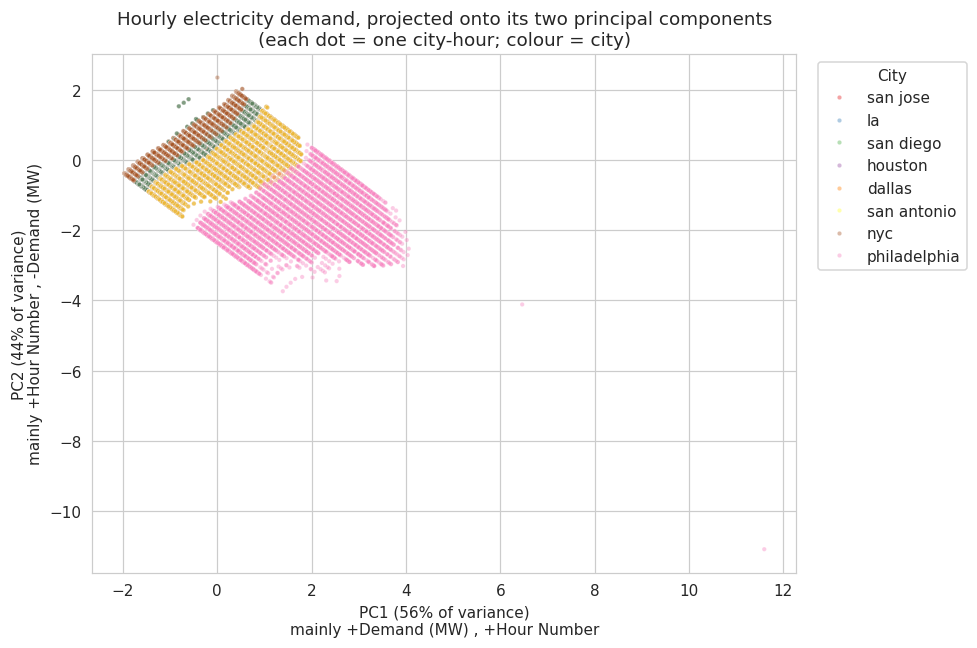

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca_hourly[:, 0], y=X_pca_hourly[:, 1],
                hue=hourly_data['city'], palette='Set1', s=8, alpha=0.4)

plt.title('Hourly electricity demand, projected onto its two principal components\n'
          '(each dot = one city-hour; colour = city)')
plt.xlabel(pc_label(pca_hourly, 0, pca_features))
plt.ylabel(pc_label(pca_hourly, 1, pca_features))
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**How to read this plot.**

- **Each dot is one city-hour** — one row of the EIA table.
- **The x-axis** is the direction of greatest spread, a blend of hour-of-day and demand.
  Moving right means moving toward later hours *and* higher load together.
- **The y-axis** is what is left over after removing the x direction: it separates hours
  where demand was unusually high *for that time of day* from hours where it was unusually low.
- **Colour is the city**, which PCA never saw. The fact that the colours form separate bands
  anyway is the real finding: cities occupy different demand ranges because they are simply
  different sizes. Los Angeles' quiet hours are busier than San Jose's peaks.

That last point is why PCA is worth doing before clustering: it shows us that **absolute
size** is the loudest signal in this data, and any clustering we run will pick up on it.

### 3.3 A second PCA: weather profiles

Now the same procedure on three genuinely different weather features. Here PCA earns its keep.

In [12]:
weather_features = ['temperature', 'humidity', 'windSpeed']

weather_profile = (weather_clean
                   .groupby(['city', 'day_of_week'])[weather_features]
                   .mean()
                   .reset_index())

X_weather_scaled = StandardScaler().fit_transform(weather_profile[weather_features])

pca_weather = PCA(n_components=2)
X_pca_weather = pca_weather.fit_transform(X_weather_scaled)

print('Explained variance:', np.round(pca_weather.explained_variance_ratio_, 3),
      f'| total kept: {pca_weather.explained_variance_ratio_.sum():.1%}')
pd.DataFrame(pca_weather.components_, columns=weather_features,
             index=['PC1', 'PC2']).round(3)

Explained variance: [0.584 0.288] | total kept: 87.2%


,temperature,humidity,windSpeed
PC1,-0.504,0.671,0.544
PC2,0.747,0.024,0.664


Now the "total kept" number matters: we went from 3 features to 2, so some information is
genuinely lost. If the two components keep ~90% of the variance, the 2-D picture below is a
faithful summary and we can trust distances in it. If they kept only ~60%, points that look
close on screen might be far apart in reality — read the plot with more caution.

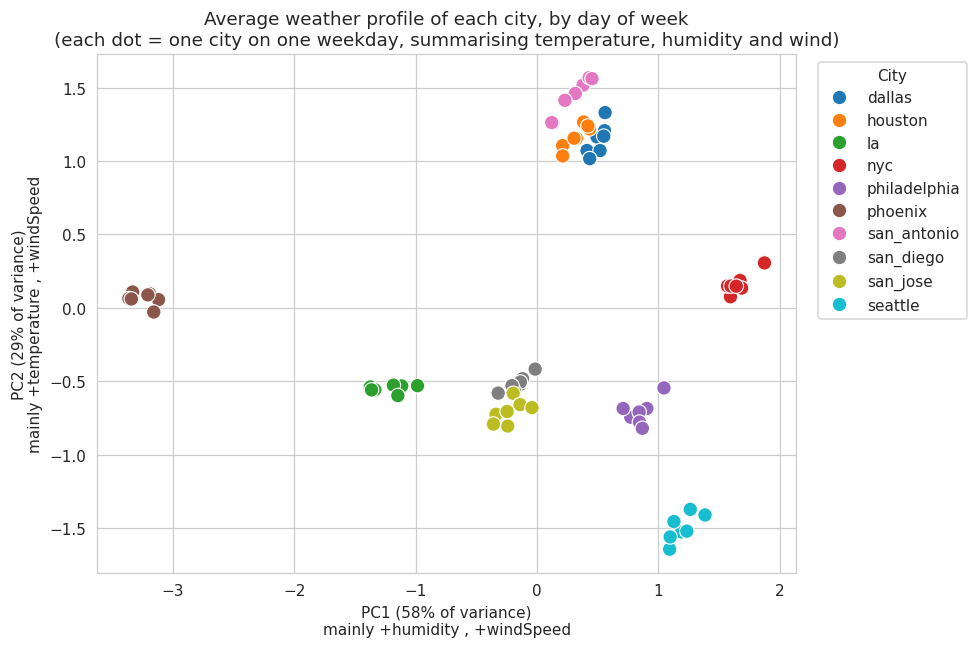

In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca_weather[:, 0], y=X_pca_weather[:, 1],
                hue=weather_profile['city'], s=90, palette='tab10')

plt.title('Average weather profile of each city, by day of week\n'
          '(each dot = one city on one weekday, summarising temperature, humidity and wind)')
plt.xlabel(pc_label(pca_weather, 0, weather_features))
plt.ylabel(pc_label(pca_weather, 1, weather_features))
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**How to read this plot.** Each city contributes seven dots, one per weekday. Two things
stand out:

- **The seven dots of a city sit almost on top of each other.** Weather does not care what
  day of the week it is — exactly what we would expect, and a useful sanity check that the
  pipeline is not scrambling anything.
- **Cities land in different regions.** The horizontal axis, driven mostly by temperature,
  separates hot dry cities (Phoenix, San Antonio) from cool damp ones (Seattle). The vertical
  axis picks up the humidity/wind contrast that temperature alone misses, which is what
  separates, say, Houston from Phoenix — both hot, very different air.

---
## 4. Building the city-day table we will cluster

PCA was for looking. Clustering needs a table where **one row = one thing we want to group**.
Our unit of analysis is a **city-day**: how did this city behave on this date?

Two features, chosen so the results stay easy to picture:

- `avg_temperature` — the day's average temperature in that city
- `avg_demand` — the day's average electricity demand in that city

We build each side separately and then join them.

**Step 1 — average temperature per city-day** (from the weather table).

In [14]:
w = weather_clean.copy()
w['city'] = w['city'].str.lower().str.replace('_', ' ').str.strip()   # match the mapping keys
w['date'] = pd.to_datetime(w['local_time']).dt.date

weather_daily = (w.groupby(['city', 'date'])['temperature']
                  .mean()
                  .reset_index(name='avg_temperature'))

print('weather_daily:', weather_daily.shape)
weather_daily.head()

weather_daily: (6920, 3)


,city,date,avg_temperature
0,dallas,2018-07-02,89.716316
1,dallas,2018-07-03,91.135833
2,dallas,2018-07-04,85.995000
3,dallas,2018-07-05,84.035833
4,dallas,2018-07-06,86.249167


**Step 2 — average demand per city-day** (from the energy table).

In [15]:
d = merged_df.copy()
d['city'] = d.apply(lambda r: rev_mapping.get((r['Balancing Authority'], r['Sub-Region'])), axis=1)
d = d.dropna(subset=['city'])
d['city'] = d['city'].str.lower().str.replace('_', ' ').str.strip()
d['date'] = pd.to_datetime(d['Local Time at End of Hour_balance']).dt.date

demand_daily = (d.groupby(['city', 'date'])['Demand (MW)']
                 .mean()
                 .reset_index(name='avg_demand'))

print('demand_daily:', demand_daily.shape)
demand_daily.head()

demand_daily: (5311, 3)


,city,date,avg_demand
0,dallas,2018-07-03,55495.130435
1,dallas,2018-07-04,47840.333333
2,dallas,2018-07-05,49510.791667
3,dallas,2018-07-06,50260.458333
4,dallas,2018-07-07,47309.125000


**Step 3 — join them.** An `inner` join keeps only city-days present in *both* tables, so we
never model a day where half the information is missing.

In [16]:
weather_daily['date'] = pd.to_datetime(weather_daily['date'])
demand_daily['date']  = pd.to_datetime(demand_daily['date'])

combined_df = pd.merge(weather_daily, demand_daily, on=['city', 'date'], how='inner').dropna()

# A couple of context columns -- NOT used for clustering, only for interpreting it later.
combined_df['month']   = combined_df['date'].dt.month
combined_df['weekday'] = combined_df['date'].dt.dayofweek
combined_df['is_weekend'] = combined_df['weekday'] >= 5

print('combined_df:', combined_df.shape, '| one row per city-day')
combined_df.head()

combined_df: (5309, 7) | one row per city-day


,city,date,avg_temperature,avg_demand,month,weekday,is_weekend
0,dallas,2018-07-03,91.135833,55495.130435,7,1,False
1,dallas,2018-07-04,85.995000,47840.333333,7,2,False
2,dallas,2018-07-05,84.035833,49510.791667,7,3,False
3,dallas,2018-07-06,86.249167,50260.458333,7,4,False
4,dallas,2018-07-07,83.653333,47309.125000,7,5,True


### Standardising before clustering

Every algorithm below measures similarity with **distance**. Temperature runs roughly 30–100
(°F) while demand runs into the thousands (MW). Left unscaled, a 1-degree temperature change
would count for nothing next to a 1-MW demand change, and the clusters would be decided by
demand alone. Standardising puts both features on the same footing so distance means
something.

In [17]:
cluster_features = ['avg_temperature', 'avg_demand']

X = combined_df[cluster_features].values
X_scaled = StandardScaler().fit_transform(X)

print('Feature matrix:', X_scaled.shape)
print('Raw ranges     :', dict(zip(cluster_features, np.round(X.max(0) - X.min(0), 1))))
print('Scaled ranges  :', dict(zip(cluster_features, np.round(X_scaled.max(0) - X_scaled.min(0), 1))))

Feature matrix: (5309, 2)
Raw ranges     : {'avg_temperature': np.float64(85.7), 'avg_demand': np.float64(114316.7)}
Scaled ranges  : {'avg_temperature': np.float64(6.1), 'avg_demand': np.float64(5.0)}


Let's look at the data we are about to cluster, before any algorithm touches it. Forming your
own expectation first is a good habit — it makes it much easier to tell a sensible clustering
from a nonsensical one.

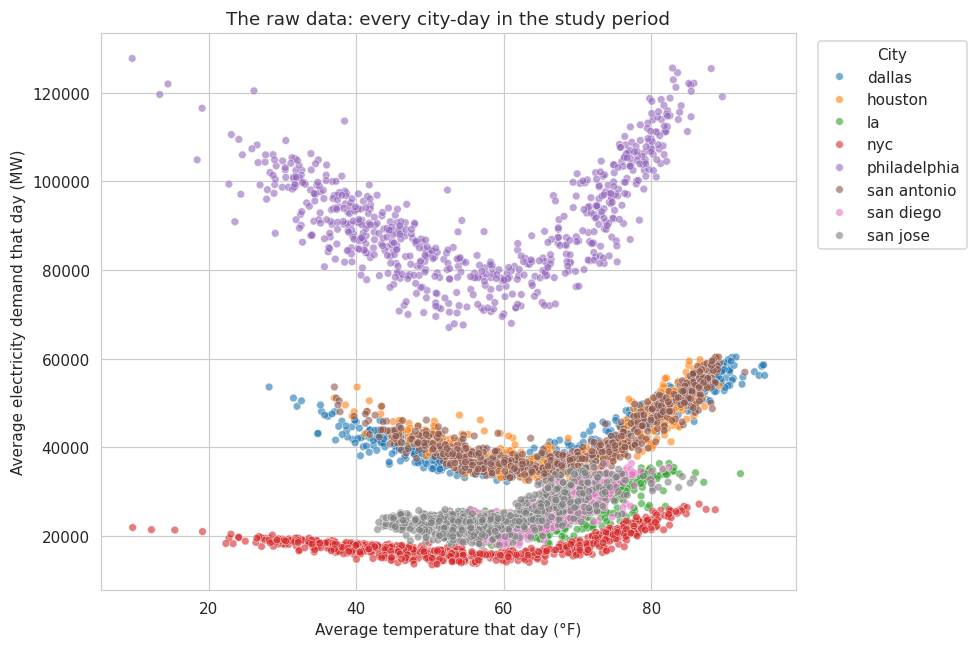

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=combined_df, x='avg_temperature', y='avg_demand',
                hue='city', s=25, alpha=0.6, palette='tab10')

plt.title('The raw data: every city-day in the study period')
plt.xlabel('Average temperature that day (°F)')
plt.ylabel('Average electricity demand that day (MW)')
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**How to read this plot.** The x-axis is how warm the day was; the y-axis is how much
electricity that city drew, averaged over the 24 hours. Each dot is one day in one city.

You should be able to see, by eye, the structure the algorithms are about to find: several
horizontal bands (big cities sit high, small cities sit low), and within the warmer bands a
distinct **upward hook on the right** — once it gets hot enough, air conditioning drives
demand up sharply.

---
## 5. K-Means clustering

K-Means splits the data into *k* groups by repeating two steps until nothing moves:

1. Assign every point to the nearest cluster centre.
2. Move each centre to the average of the points assigned to it.

It minimises **inertia** — the total squared distance from each point to its own centre.
You must choose *k* yourself, so we start there.

### 5.1 Choosing *k* with the elbow method

Inertia always falls as *k* rises (with one cluster per point it hits zero), so "lowest
inertia" is not a useful rule. Instead we look for the **elbow**: the point where adding
another cluster stops buying a big improvement.

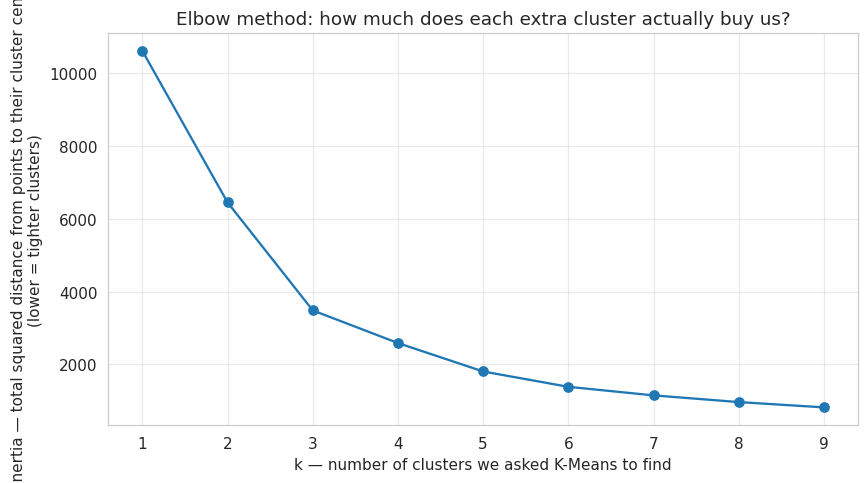

In [19]:
from sklearn.cluster import KMeans

K_range = range(1, 10)
inertia = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(list(K_range), inertia, 'o-')
plt.title('Elbow method: how much does each extra cluster actually buy us?')
plt.xlabel('k — number of clusters we asked K-Means to find')
plt.ylabel('Inertia — total squared distance from points to their cluster centre\n(lower = tighter clusters)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Reading the elbow.** Going from k=1 to k=2 to k=3 drops inertia steeply — those splits are
finding real structure. After that the curve flattens: extra clusters are slicing groups that
were already coherent. The bend around **k=3** is our elbow, so that's what we'll fit.

Be honest about the limits of this method: the elbow is a judgement call, not a calculation,
and on smooth data there may not be an obvious bend at all. That is why we back it up with
the numerical scores in section 8.

### 5.2 Fitting K-Means with k=3

In [20]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
combined_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(combined_df['kmeans_cluster'].value_counts().sort_index()
      .rename('city-days').to_frame())

                city-days
kmeans_cluster           
0                    2673
1                    1972
2                     664


Check the sizes before anything else. Roughly comparable groups suggest the algorithm found
genuine structure. One giant cluster plus two tiny ones usually means K-Means is being used
to isolate outliers rather than to describe the bulk of the data.

In [21]:
# Put the cluster centres back on the original scale so they are interpretable.
centres = pd.DataFrame(
    StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)
centres.index.name = 'cluster'
centres.round(1)

,avg_temperature,avg_demand
cluster,,
0,55.1,26647.9
1,76.7,38468.3
2,55.7,91365.8


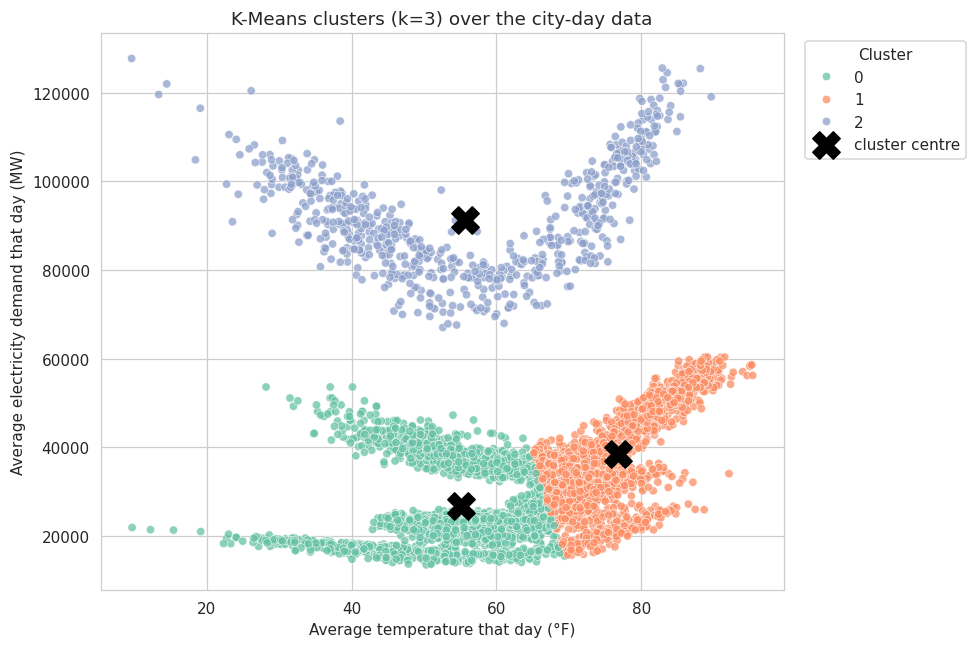

In [22]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=combined_df, x='avg_temperature', y='avg_demand',
                hue='kmeans_cluster', palette='Set2', s=30, alpha=0.75)
plt.scatter(centres['avg_temperature'], centres['avg_demand'],
            marker='X', s=320, c='black', label='cluster centre', zorder=5)

plt.title('K-Means clusters (k=3) over the city-day data')
plt.xlabel('Average temperature that day (°F)')
plt.ylabel('Average electricity demand that day (MW)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**How to read this plot.** Same axes as the raw scatter above — temperature across,
demand up — but now colour shows the group K-Means assigned, and the black X marks each
group's centre.

Notice that the boundaries are essentially **horizontal**. K-Means split the data mostly by
demand level, barely by temperature. That is not a bug: after standardising, demand simply
varies more across this dataset than temperature does, because it mixes cities of very
different sizes. Section 9 comes back to what that means.

---
## 6. Hierarchical (agglomerative) clustering

Hierarchical clustering takes a different route. It starts with every point as its own
cluster, then repeatedly merges the two closest clusters until only one remains. The record
of those merges is a tree — a **dendrogram** — and you pick your clusters by cutting it at a
chosen height.

The advantage over K-Means: you do not commit to *k* in advance. You get the whole family of
solutions and choose afterwards. The cost: it is much more expensive on large datasets,
because it has to consider distances between all pairs.

We use **Ward linkage**, which merges the pair of clusters that increases within-cluster
variance the least — the same objective K-Means optimises, approached bottom-up.

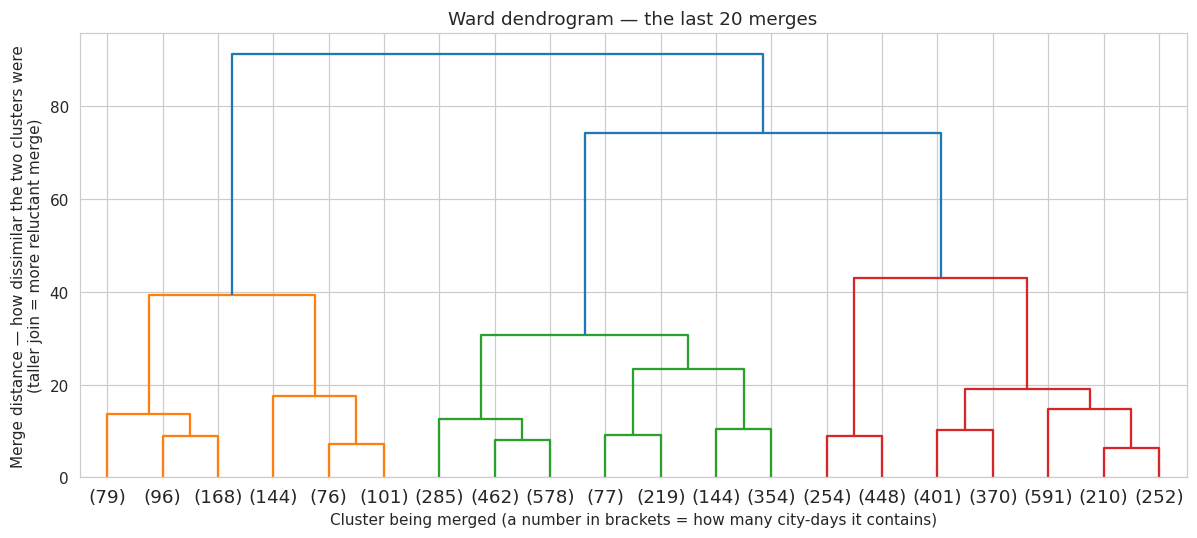

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Ward dendrogram — the last 20 merges')
plt.xlabel('Cluster being merged (a number in brackets = how many city-days it contains)')
plt.ylabel('Merge distance — how dissimilar the two clusters were\n(taller join = more reluctant merge)')
plt.tight_layout()
plt.show()

**How to read a dendrogram.** Read it bottom to top. Each horizontal bar is a merge; its
**height** is how far apart the two merged clusters were. Short bars near the bottom are easy,
obvious merges. A tall bar means the algorithm joined two groups that were genuinely
dissimilar — it had run out of better options.

To choose *k*, imagine drawing a horizontal line across the plot and count the vertical lines
it crosses. Cut through the tall, empty gap near the top and you get a small number of
well-separated clusters. Here the largest vertical gap suggests **2 or 3** — reassuringly
consistent with what the elbow told us.

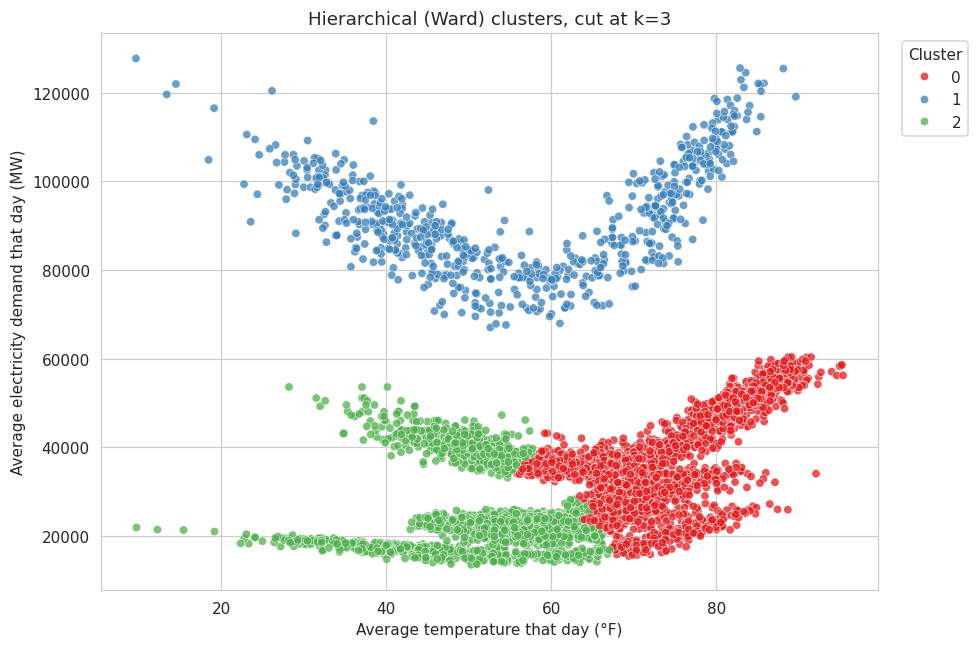

In [24]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
combined_df['hc_cluster'] = agg.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=combined_df, x='avg_temperature', y='avg_demand',
                hue='hc_cluster', palette='Set1', s=30, alpha=0.75)
plt.title('Hierarchical (Ward) clusters, cut at k=3')
plt.xlabel('Average temperature that day (°F)')
plt.ylabel('Average electricity demand that day (MW)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Compare this against the K-Means plot. The regions are similar but the boundaries are not
identical, and the cluster *numbers* are arbitrary — cluster 0 here has nothing to do with
cluster 0 there. **Cluster labels carry no meaning across algorithms, or even across reruns.**
Always compare clusters by their contents, never by their ID.

In [25]:
# How much do the two methods actually agree? Rows = K-Means, columns = Hierarchical.
pd.crosstab(combined_df['kmeans_cluster'], combined_df['hc_cluster'],
            rownames=['K-Means'], colnames=['Hierarchical'])

Hierarchical,0,1,2
K-Means,,,
0,554,0,2119
1,1972,0,0
2,0,664,0


In a table like this, agreement shows up as **one large value per row and column** — each
K-Means cluster mapping cleanly onto one hierarchical cluster. Values spread evenly across a
row mean that group is being split differently by the two methods, which is a sign the
boundary there is not well determined by the data.

---
## 7. DBSCAN — density-based clustering

DBSCAN works from a completely different idea: **a cluster is a dense region of points.**
It has two knobs:

- `eps` — the neighbourhood radius around a point (in *scaled* units here).
- `min_samples` — how many neighbours within `eps` a point needs to count as a "core" point.

Points in dense regions get grouped; points in sparse regions are labelled **noise** (`-1`).

Two consequences worth knowing:

- **You never specify k.** The number of clusters falls out of the density structure.
- **Clusters can be any shape.** K-Means can only make roughly spherical blobs; DBSCAN can
  trace a long curved band, like the temperature-demand hook in our data.

The price is that DBSCAN is very sensitive to `eps`. Too small and everything is noise; too
large and everything merges into one blob.

In [26]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
combined_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

counts = combined_df['dbscan_cluster'].value_counts().sort_index()
n_noise = (combined_df['dbscan_cluster'] == -1).sum()

print('Cluster sizes (-1 = noise):')
print(counts.to_string())
print(f'\nClusters found : {(counts.index != -1).sum()}')
print(f'Flagged as noise: {n_noise} city-days ({n_noise / len(combined_df):.1%})')

Cluster sizes (-1 = noise):
dbscan_cluster
-1       2
 0    4644
 1     663

Clusters found : 2
Flagged as noise: 2 city-days (0.0%)


**Reading these counts.** The noise percentage is the number to watch. A few percent is
healthy — genuinely unusual days that do not belong anywhere. Twenty or thirty percent means
`eps` is too tight, and DBSCAN is discarding data rather than describing it. If you see one
enormous cluster and nothing else, `eps` is too loose. Try `eps=0.3` and `eps=0.8` afterwards
to feel how sharply the result swings.

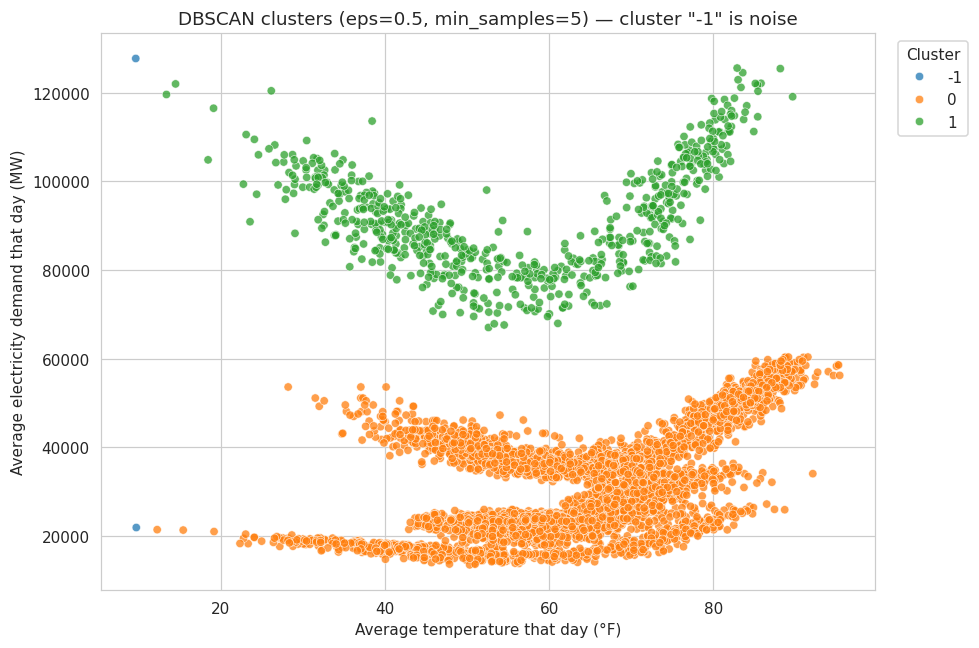

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=combined_df, x='avg_temperature', y='avg_demand',
                hue='dbscan_cluster', palette='tab10', s=30, alpha=0.75)
plt.title('DBSCAN clusters (eps=0.5, min_samples=5) — cluster "-1" is noise')
plt.xlabel('Average temperature that day (°F)')
plt.ylabel('Average electricity demand that day (MW)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Look at where the noise points land: scattered around the sparse edges of the cloud —
unusually hot days, unusually low-demand days. For a grid operator those are exactly the days
worth investigating, so DBSCAN's "failures" double as an anomaly detector.

---
## 8. Evaluating clusters without labels

This is the part that separates clustering from every supervised model you have built so far.
There is no ground truth, so we cannot compute accuracy. Instead we use **internal metrics**,
which score the *geometry* of the result: are the clusters tight, and are they far apart?

We use three, because each can be fooled in a different way.

### The three metrics, in plain language

**Silhouette score — range −1 to 1, higher is better.**
For each point, compare `a` (its average distance to other points in its own cluster) with
`b` (its average distance to points in the nearest *other* cluster). The silhouette is
`(b − a) / max(a, b)`. Near **+1**: the point is much closer to its own group than to any
other — well placed. Near **0**: it sits on the boundary and could plausibly belong to either.
**Negative**: it is closer to a different cluster than its own — probably misassigned. The
reported score averages this over all points.

Rough reading: above **0.5** is a strong structure; **0.25–0.5** is reasonable but overlapping;
below **0.25** means the clusters are not well separated and you should be sceptical of them.

**Davies–Bouldin index — 0 upward, LOWER is better.**
For every pair of clusters it computes (their combined internal spread) ÷ (the distance
between their centres), and reports the worst case averaged over clusters. It answers: *is
any pair of clusters too close given how spread out they are?* 0 would be perfect separation;
values under ~1 are generally good.

**Calinski–Harabasz index — 0 upward, higher is better.**
The ratio of between-cluster variance to within-cluster variance. There is no absolute scale,
so the number alone is meaningless — it is only useful for **comparing** clusterings on the
same dataset.

In [28]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def score_clustering(name, X_data, labels):
    """Score one clustering with all three internal metrics."""
    return {
        'method':            name,
        'n_clusters':        len(set(labels)),
        'silhouette':        silhouette_score(X_data, labels),
        'davies_bouldin':    davies_bouldin_score(X_data, labels),
        'calinski_harabasz': calinski_harabasz_score(X_data, labels),
    }

rows = [
    score_clustering('K-Means (k=3)',      X_scaled, combined_df['kmeans_cluster']),
    score_clustering('Hierarchical (k=3)', X_scaled, combined_df['hc_cluster']),
]

# DBSCAN is only scoreable on its non-noise points, and only if it found >1 real cluster.
mask = combined_df['dbscan_cluster'] != -1
if combined_df.loc[mask, 'dbscan_cluster'].nunique() > 1:
    rows.append(score_clustering('DBSCAN (excl. noise)',
                                 X_scaled[mask.values], combined_df.loc[mask, 'dbscan_cluster']))

metrics_table = pd.DataFrame(rows).set_index('method')
metrics_table.round(3)

,n_clusters,silhouette,davies_bouldin,calinski_harabasz
method,,,,
K-Means (k=3),3,0.466,0.742,5430.860
Hierarchical (k=3),3,0.426,0.792,4981.865
DBSCAN (excl. noise),2,0.567,0.797,3425.181


### What this table is telling us

Go across the row for each method and read the three numbers **together**:

- **Silhouette** — is each city-day comfortably inside its own cluster? Check your value against
  the rough guide above. Expect something respectable but not spectacular: the clusters here are
  real, yet their edges genuinely blur, because a 78°F day and a 79°F day are not meaningfully
  different and still have to be assigned to one side of a boundary.
- **Davies–Bouldin** — are any two clusters uncomfortably close relative to their own width?
  The method with the lowest value here has the cleanest separation between neighbouring
  groups.
- **Calinski–Harabasz** — which method concentrated the most variance *between* clusters
  rather than *within* them? Compare across rows only; the raw number means nothing on its own.

**The result to take away:** when all three metrics point the same way, you can be reasonably
confident. When they disagree, the structure is weak and the "best" clustering is largely a
matter of which definition of "good" you picked. Note also that DBSCAN's score is computed
after dropping its noise points, which flatters it — it is being graded on the easy cases
only, so do not compare it to the others at face value.

### Silhouette across different values of k

A single silhouette number is more useful when you can see it in context. Recomputing it for
several *k* gives an independent second opinion on the elbow plot.

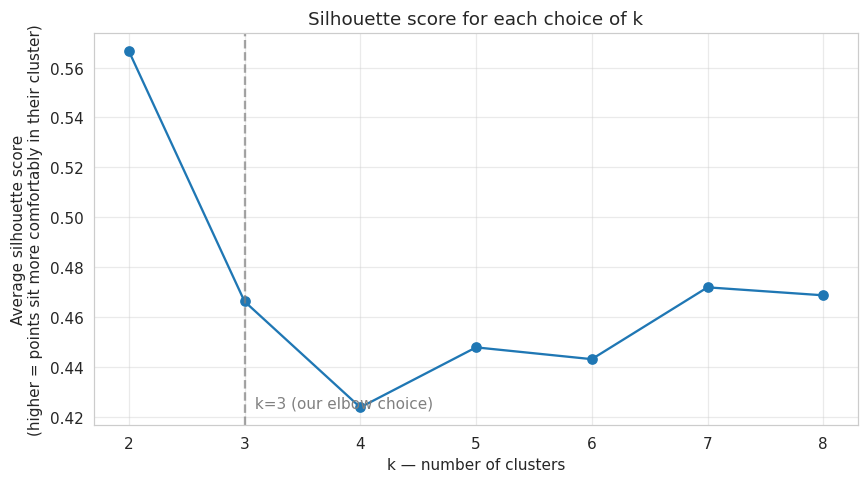

,k,silhouette
0,2,0.567
1,3,0.466
2,4,0.424
3,5,0.448
4,6,0.443
5,7,0.472
6,8,0.469


In [29]:
sil_by_k = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled)
    sil_by_k.append({'k': k, 'silhouette': silhouette_score(X_scaled, labels)})

sil_df = pd.DataFrame(sil_by_k)

plt.figure(figsize=(8, 4.5))
plt.plot(sil_df['k'], sil_df['silhouette'], 'o-')
plt.axvline(3, color='grey', ls='--', alpha=0.7)
plt.text(3.05, sil_df['silhouette'].min(), ' k=3 (our elbow choice)', color='grey')
plt.title('Silhouette score for each choice of k')
plt.xlabel('k — number of clusters')
plt.ylabel('Average silhouette score\n(higher = points sit more comfortably in their cluster)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

sil_df.round(3)

**Reading this curve.** The peak is the *k* the geometry prefers. If it lands on the same
value the elbow suggested, two independent criteria agree and the choice is solid. If they
disagree — say the elbow says 3 and silhouette peaks at 2 — neither is wrong; they optimise
different things. Break the tie on whichever number of groups you can actually explain and
act on.

---
## 9. What is the data actually telling us?

Metrics tell us whether the clusters are geometrically sound. They say nothing about whether
the clusters *mean* anything. For that we go back to the domain: describe each group in
ordinary language and see whether the description makes sense.

In [30]:
profile = combined_df.groupby('kmeans_cluster').agg(
    city_days       = ('date', 'count'),
    avg_temperature = ('avg_temperature', 'mean'),
    avg_demand      = ('avg_demand', 'mean'),
    coolest_day     = ('avg_temperature', 'min'),
    hottest_day     = ('avg_temperature', 'max'),
    weekend_share   = ('is_weekend', 'mean'),
).round(1)

profile['share_of_data'] = (profile['city_days'] / len(combined_df) * 100).round(1)
profile

,city_days,avg_temperature,avg_demand,coolest_day,hottest_day,weekend_share,share_of_data
kmeans_cluster,,,,,,,
0,2673,55.0,26652.3,9.7,69.4,0.3,50.3
1,1972,76.7,38414.3,65.1,95.4,0.3,37.1
2,664,55.7,91365.8,9.6,89.6,0.3,12.5


Which cities and which months end up in each cluster?

Share of each cluster made up by each city:


city,dallas,houston,la,nyc,philadelphia,san antonio,san diego,san jose
kmeans_cluster,,,,,,,,
0,12.1,8.9,15.6,17.5,0.0,9.7,17.4,18.8
1,17.1,21.6,12.6,9.9,0.0,20.4,10.1,8.2
2,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0


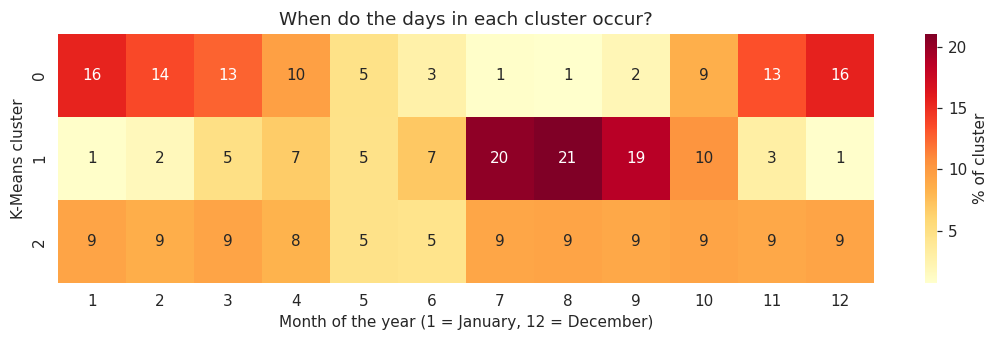

In [31]:
city_mix = pd.crosstab(combined_df['kmeans_cluster'], combined_df['city'], normalize='index')
print('Share of each cluster made up by each city:')
display((city_mix * 100).round(1))

month_mix = pd.crosstab(combined_df['kmeans_cluster'], combined_df['month'], normalize='index')
plt.figure(figsize=(10, 3.2))
sns.heatmap(month_mix * 100, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '% of cluster'})
plt.title('When do the days in each cluster occur?')
plt.xlabel('Month of the year (1 = January, 12 = December)')
plt.ylabel('K-Means cluster')
plt.tight_layout()
plt.show()

**How to read the heatmap.** Each row is one cluster and adds up to 100% across the year.
A row with colour spread evenly across all twelve months contains days from every season —
that cluster is defined by *place*, not *time*. A row concentrated in the summer or winter
columns is a seasonal cluster, defined by *weather*.

### Summary of insights

Putting the profile table, the city mix and the seasonal heatmap together:

**1. City size is the loudest signal.** Look at the `avg_demand` column of the profile table:
the clusters are separated far more by *how much power a place uses* than by *how hot the day
was*. A quiet night in the Los Angeles service area still draws more power than a peak afternoon
in San Jose. Because we clustered on raw megawatts, absolute scale was always going to dominate —
and the city-mix table confirms it, with most clusters made up of a small handful of cities.

**2. Temperature does get a cluster, but only at the extreme.** Typically one group emerges with
a clearly higher average temperature — the hot-weather, air-conditioning days. Read its month
row in the heatmap: it should concentrate in the summer columns. But the *cold* end of the
relationship does not get its own cluster, and that is the interesting failure. Within each
city's band the temperature–demand relationship is a **U** — high demand when cold (heating),
lowest in the mild 60s°F, rising again when hot. K-Means can only carve out roughly circular
blobs, so it captures the hot arm of the U and misses the cold one. That is a limitation of the
algorithm, not a shortage of signal in the data.

**3. The clusters overlap because the underlying variable is continuous.** Silhouette scores
in the moderate range are the honest answer here. Days do not come in discrete types; they
form a continuum, and any partition of a continuum will have blurry edges. Clustering is
still useful — it just should not be oversold as discovering natural kinds.

**4. DBSCAN's noise points are the interesting days.** The city-days it refused to assign sit
at the extremes: heatwaves, cold snaps, unusually quiet days. For a grid operator these are
precisely the days worth a second look, which makes DBSCAN's rejects a free anomaly detector.

**5. What we would do differently next.** To surface *weather-driven* behaviour rather than
*city-size* behaviour, normalise demand within each city first — for example, cluster on
`demand / that city's average demand`. That removes size from the picture and lets the
temperature response become the dominant signal. The exercise below starts you down this path.

---
## 10. t-SNE (optional)

t-SNE is another way to get to two dimensions, but its goal is different from PCA's. PCA
preserves **global** structure — large distances stay meaningful. t-SNE preserves **local**
structure: it tries to keep each point's nearest neighbours nearby, and cheerfully distorts
everything else to make groups visually distinct.

Two warnings that matter:

- **Distances between clusters in a t-SNE plot are not meaningful.** Two blobs drawn far
  apart are not necessarily more different than two drawn close together.
- **It is visualisation only.** There is no `transform()` for new data, so you cannot use it
  inside a modelling pipeline the way you can with PCA.

With only two features here it is illustrative rather than necessary — t-SNE earns its keep
when you have dozens of dimensions.

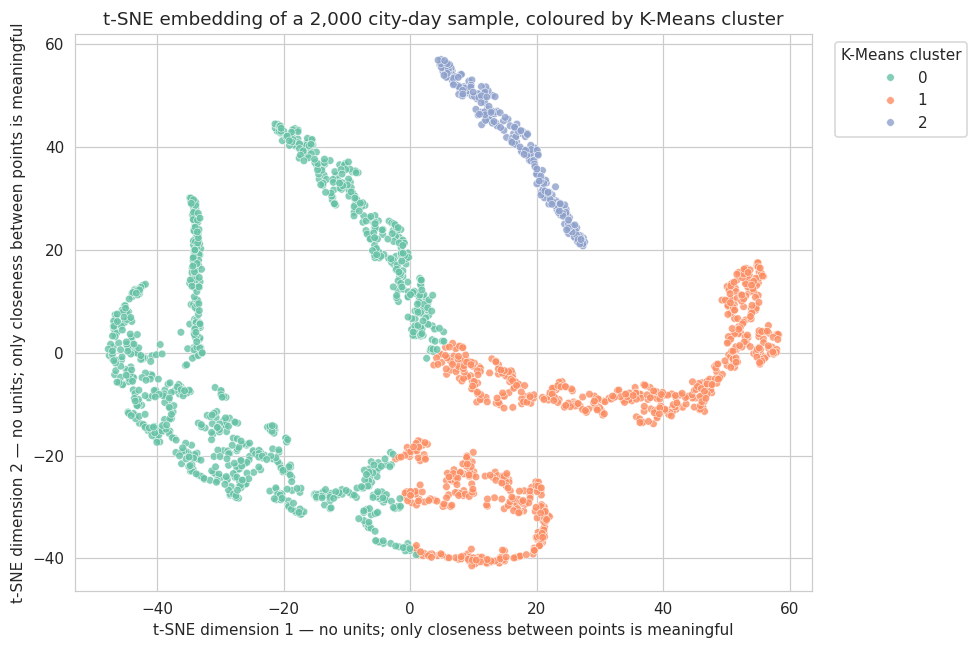

In [32]:
from sklearn.manifold import TSNE

# t-SNE is slow and scales poorly, so run it on a random sample.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_scaled), size=min(2000, len(X_scaled)), replace=False)

emb = TSNE(n_components=2, random_state=RANDOM_STATE,
           perplexity=30, init='pca').fit_transform(X_scaled[sample_idx])

plt.figure(figsize=(9, 6))
sns.scatterplot(x=emb[:, 0], y=emb[:, 1],
                hue=combined_df['kmeans_cluster'].values[sample_idx],
                palette='Set2', s=25, alpha=0.8)
plt.title('t-SNE embedding of a 2,000 city-day sample, coloured by K-Means cluster')
plt.xlabel('t-SNE dimension 1 — no units; only closeness between points is meaningful')
plt.ylabel('t-SNE dimension 2 — no units; only closeness between points is meaningful')
plt.legend(title='K-Means cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**How to read this plot.** Unlike every earlier scatter, **the axes have no interpretation**
— that is why they are labelled the way they are. The only thing you should read off this
plot is *which points ended up near which other points*. If the K-Means colours form coherent
patches, the clustering is consistent with the local neighbourhood structure t-SNE found.
Colours smeared through each other would tell us the clusters are not well separated even
locally.

---
## 11. Exercise

**Goal:** add a third feature, re-cluster, and judge the result with the metrics from
section 8.

1. Compute `avg_humidity` per city-day and merge it into `combined_df`.
2. Build and standardise a 3-feature matrix: `[avg_temperature, avg_demand, avg_humidity]`.
3. Fit K-Means for `k = 2, 3, 4, 5` and print the silhouette score for each.
4. Pick the best *k*, refit, and plot two of the three features coloured by cluster —
   with informative axis labels.
5. **Write two or three sentences** describing what your clusters represent, using a
   `groupby` profile table like the one in section 9. Did adding humidity change the story?

**Stretch:** replace `avg_demand` with **demand relative to that city's own average**
(`avg_demand / city mean`) and re-run. Does the city-size effect disappear? What replaces it?

k=2  silhouette=0.436
k=3  silhouette=0.307
k=4  silhouette=0.333
k=5  silhouette=0.344

Best k: 2
Best silhouette score: 0.436


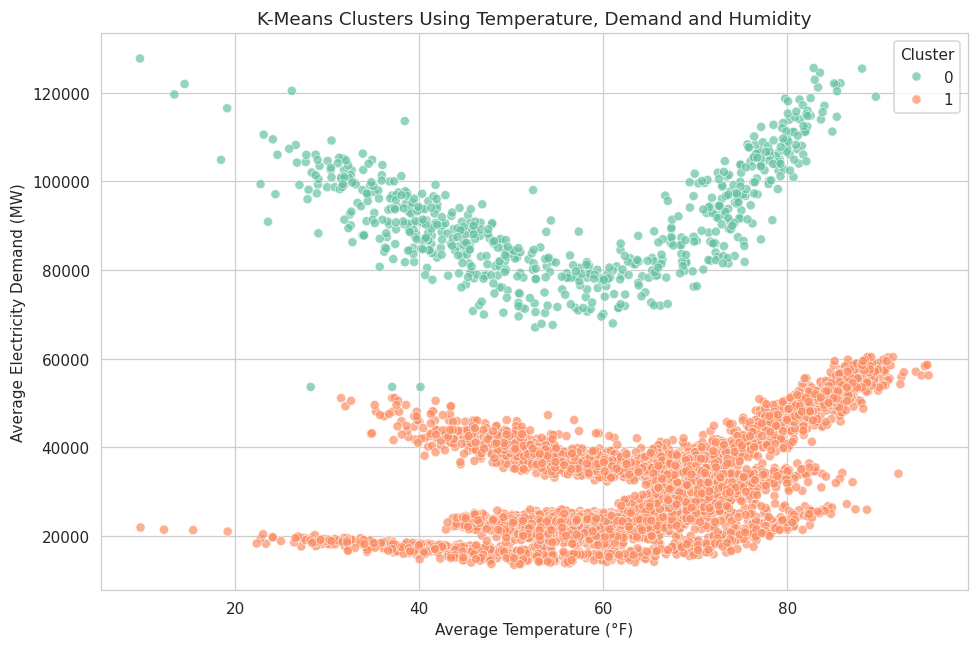

,city_days,avg_temperature,avg_demand,avg_humidity
cluster_3features,,,,
0,667,55.62,91195.79,0.69
1,4642,64.26,31631.61,0.68


In [34]:
# --- Exercise solution ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Average humidity per city-day, merged in
hum = w.groupby(['city', 'date'])['humidity'].mean().reset_index(name='avg_humidity')
hum['date'] = pd.to_datetime(hum['date'])

combined_df = combined_df.merge(
    hum,
    on=['city', 'date'],
    how='left'
).dropna(subset=['avg_humidity'])

# 2. Build and scale the 3-feature matrix
X3 = combined_df[
    ['avg_temperature', 'avg_demand', 'avg_humidity']
].values

X3_scaled = StandardScaler().fit_transform(X3)

# 3. Try several k values
scores = {}

for k in [2, 3, 4, 5]:
    labels = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    ).fit_predict(X3_scaled)

    score = silhouette_score(X3_scaled, labels)
    scores[k] = score

    print(f'k={k}  silhouette={score:.3f}')

# Choose the k with the highest silhouette score
best_k = max(scores, key=scores.get)

print('\nBest k:', best_k)
print('Best silhouette score:', round(scores[best_k], 3))

# 4. Refit K-Means using the best k
kmeans3 = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

combined_df['cluster_3features'] = kmeans3.fit_predict(X3_scaled)

# Plot two of the three features
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=combined_df,
    x='avg_temperature',
    y='avg_demand',
    hue='cluster_3features',
    palette='Set2',
    alpha=0.7
)

plt.title('K-Means Clusters Using Temperature, Demand and Humidity')
plt.xlabel('Average Temperature (°F)')
plt.ylabel('Average Electricity Demand (MW)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

# 5. Profile the clusters
profile_3features = combined_df.groupby('cluster_3features').agg(
    city_days=('date', 'count'),
    avg_temperature=('avg_temperature', 'mean'),
    avg_demand=('avg_demand', 'mean'),
    avg_humidity=('avg_humidity', 'mean')
).round(2)

profile_3features

The best number of clusters is 2, with a silhouette score of 0.436. Cluster 0 represents city-days with much higher electricity demand, while Cluster 1 represents lower-demand city-days. Adding humidity did not change the story much because the average humidity is very similar between the two clusters (0.69 vs. 0.68).